# Gauss, Radau and Lobatto nodes: the building blocks of collocation

Collocation methods and pseudospectral transcriptions rest on a few objects: a set of nodes in an
interval, the Lagrange polynomials through them, and three matrices built from those polynomials,
which integrate, differentiate and interpolate values given at the nodes. `scaly.integrators.polynomial`
constructs them in NumPy, and the collocation tableaus of `si.gauss_legendre`, `si.radau_iia` and
`si.lobatto_iiia` are made from them.

This notebook checks each object against what the theory says it must be: the degree of polynomial
each quadrature integrates exactly and not one degree more, exactness and spectral convergence of
differentiation and interpolation, the published coefficients and orders of the collocation
methods. It ends with a small generated Function, a spectral derivative and integral of sampled
data with the matrices folded into the C.

| Scaly feature | Where |
| --- | --- |
| `polynomial.gauss_nodes`, `radau_nodes`, `lobatto_nodes`, `interpolation_matrix` | Nodes and the Lagrange basis |
| `polynomial.lagrange_integrals` | Quadrature |
| `polynomial.differentiation_matrix`, `interpolation_matrix` | Differentiation and interpolation |
| `si.gauss_legendre`, `si.radau_iia`, `si.lobatto_iiia`, `si.order_conditions` | Collocation tableaus |
| `sc.function` with `sc.const` matrices, `write_module` | A generated spectral derivative, The generated C |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module
from scaly.integrators import polynomial

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "polynomials"

## Nodes and the Lagrange basis

With $P_n$ the Legendre polynomial of degree $n$, mapped from $[-1, 1]$ to $[0, 1]$, the three node
families of $n$ points are:

* Gauss, or Legendre-Gauss: the roots of $P_n$, all inside $(0, 1)$;
* Radau, or right Legendre-Gauss-Radau: the roots of $P_n - P_{n-1}$, the last of which is 1;
* Lobatto, or Legendre-Gauss-Lobatto: 0, 1 and the roots of $P_{n-1}'$.

The Lagrange polynomial $l_j$ is the polynomial of degree $n - 1$ that is 1 at node $j$ and 0 at the
others, $l_j(t) = \prod_{m \ne j} (t - t_m)/(t_j - t_m)$. `interpolation_matrix(nodes, at)` holds
$l_j$ evaluated at the points `at`, one column per node.

   gauss, n = 4: [0.069432 0.330009 0.669991 0.930568]
   radau, n = 4: [0.088588 0.409467 0.787659 1.      ]
 lobatto, n = 4: [0.       0.276393 0.723607 1.      ]


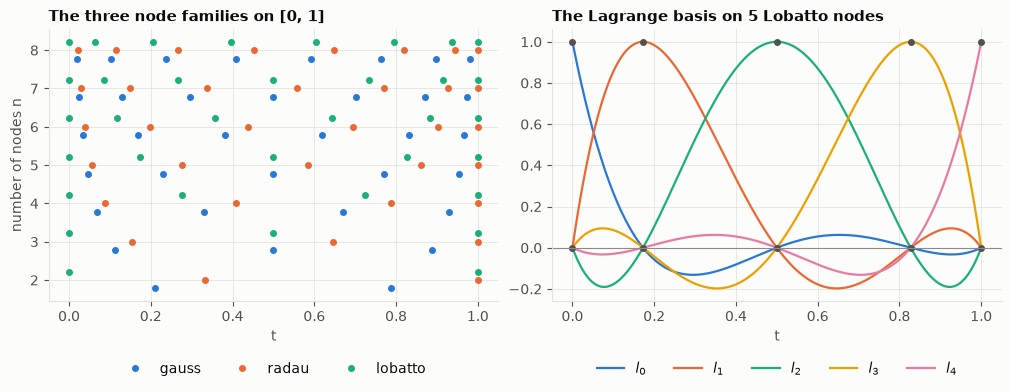

In [2]:
FAMILIES = {"gauss": polynomial.gauss_nodes, "radau": polynomial.radau_nodes, "lobatto": polynomial.lobatto_nodes}
COLORS = {"gauss": plotstyle.BLUE, "radau": plotstyle.ORANGE, "lobatto": plotstyle.AQUA}
for name, nodes_of in FAMILIES.items():
  print(f"{name:>8}, n = 4: {np.array2string(nodes_of(4), precision=6)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for offset, (name, nodes_of) in zip((-0.22, 0.0, 0.22), FAMILIES.items(), strict=True):
  for n in range(2, 9):
    ax1.plot(nodes_of(n), np.full(n, n + offset), "o", color=COLORS[name], ms=4, label=name if n == 2 else None)
ax1.set_xlabel("t")
ax1.set_ylabel("number of nodes n")
ax1.set_title("The three node families on [0, 1]")
ax1.legend(loc="upper center", ncols=3, bbox_to_anchor=(0.5, -0.18))
nodes = polynomial.lobatto_nodes(5)
fine = np.linspace(0.0, 1.0, 301)
basis = polynomial.interpolation_matrix(nodes, fine)
for j, color in enumerate(plotstyle.SERIES[:5]):
  ax2.plot(fine, basis[:, j], color=color, lw=1.6, label=f"$l_{j}$")
ax2.plot(nodes, np.ones_like(nodes), "o", color=plotstyle.TEXT_SECONDARY, ms=4)
ax2.plot(nodes, np.zeros_like(nodes), "o", color=plotstyle.TEXT_SECONDARY, ms=4)
ax2.axhline(0, color=plotstyle.NEUTRAL, lw=0.8)
ax2.set_xlabel("t")
ax2.set_title("The Lagrange basis on 5 Lobatto nodes")
ax2.legend(loc="upper center", ncols=5, bbox_to_anchor=(0.5, -0.18))
plt.show()

The nodes cluster towards the ends of the interval as $n$ grows, like Chebyshev points, which is
what keeps interpolation on them stable. Radau adds the right end, Lobatto both ends: those are the
families a collocation interval uses when it must share its end state with the next interval.

## Quadrature

`lagrange_integrals(nodes, upper)` returns $\int_0^{u_i} l_j(t)\, dt$ for each upper limit $u_i$.
With the one upper limit 1, the row is the quadrature weights $w_j$, and
$\int_0^1 p \approx \sum_j w_j\, p(t_j)$. A rule on $n$ nodes built this way is exact for degree
$n - 1$ at least, and the choice of nodes buys more: Gauss nodes reach degree $2n - 1$, Radau nodes,
with one node fixed, $2n - 2$, and Lobatto nodes, with two fixed, $2n - 3$. The check integrates the
monomials $t^k$, whose integral is $1/(k + 1)$, and finds the first degree the rule misses.

highest degree integrated exactly, n = 2..8
     gauss:  3  5  7  9 11 13 15   (one degree more misses by 3.6e-10 or more)
     radau:  2  4  6  8 10 12 14   (one degree more misses by 1.5e-09 or more)
   lobatto:  1  3  5  7  9 11 13   (one degree more misses by 6.5e-09 or more)
   gauss weights, n = 3: [0.277778 0.444444 0.277778]
   radau weights, n = 3: [0.376403 0.512486 0.111111]
 lobatto weights, n = 3: [0.166667 0.666667 0.166667]


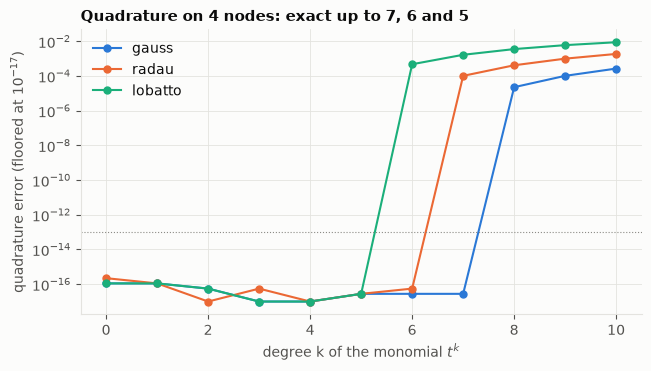

In [3]:
QUADRATURE_POINTS = range(2, 9)
EXACT = 1e-13  # below this a quadrature or derivative error is rounding


def exact_degree(nodes: np.ndarray) -> tuple[int, float]:
  """The highest degree the quadrature on ``nodes`` integrates exactly over [0, 1], and its error one degree up."""
  weights = polynomial.lagrange_integrals(nodes, np.ones(1))[0]
  degree = 0
  while abs(weights @ nodes**degree - 1 / (degree + 1)) < EXACT:
    degree += 1
  return degree - 1, float(abs(weights @ nodes**degree - 1 / (degree + 1)))


degrees = {name: [exact_degree(nodes_of(n)) for n in QUADRATURE_POINTS] for name, nodes_of in FAMILIES.items()}
quadrature_degree = {name: [d for d, _ in rows] for name, rows in degrees.items()}
quadrature_next_degree_error = {name: min(e for _, e in rows) for name, rows in degrees.items()}
print(f"highest degree integrated exactly, n = {QUADRATURE_POINTS.start}..{QUADRATURE_POINTS.stop - 1}")
for name, row in quadrature_degree.items():
  print(f"  {name:>8}: {' '.join(f'{d:>2}' for d in row)}   (one degree more misses by {quadrature_next_degree_error[name]:.1e} or more)")
for name, nodes_of in FAMILIES.items():
  print(f"{name:>8} weights, n = 3: {np.array2string(polynomial.lagrange_integrals(nodes_of(3), np.ones(1))[0], precision=6)}")

N_SHOWN = 4
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for name, nodes_of in FAMILIES.items():
  nodes = nodes_of(N_SHOWN)
  weights = polynomial.lagrange_integrals(nodes, np.ones(1))[0]
  ks = np.arange(0, 2 * N_SHOWN + 3)
  errors = np.array([abs(weights @ nodes**k - 1 / (k + 1)) for k in ks])
  ax.semilogy(ks, np.maximum(errors, 1e-17), "o-", color=COLORS[name], label=name, lw=1.5)
ax.axhline(EXACT, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax.set_xlabel("degree k of the monomial $t^k$")
ax.set_ylabel(r"quadrature error (floored at $10^{-17}$)")
ax.set_title(f"Quadrature on {N_SHOWN} nodes: exact up to 7, 6 and 5")
ax.legend()
plt.show()

The degrees come out exactly $2n - 1$, $2n - 2$ and $2n - 3$ for every $n$ from 2 to 8, and the
first degree missed is missed by $3.6 \times 10^{-10}$ or more, far above the $10^{-13}$ taken as
rounding. Lobatto's three-point weights are Simpson's rule, $(1/6, 2/3, 1/6)$.

## Differentiation and interpolation

The differentiation matrix $D_{ij} = l_j'(t_i)$ maps values at the nodes to the derivative, at the
nodes, of the polynomial through them. From the barycentric weights $\beta_j = 1/\prod_{m \ne j}(t_j - t_m)$,

$$
D_{ij} = \frac{\beta_j / \beta_i}{t_i - t_j} \quad (i \ne j), \qquad D_{ii} = -\sum_{j \ne i} D_{ij} .
$$

It is exact on polynomials of degree $n - 1$. On a smooth function the interpolant's error falls
faster than any power of $1/n$, so the derivative and the values between nodes converge
exponentially: spectral accuracy. The test function is $f(t) = e^{\sin 3t}$ on $[0, 1]$, with
$f'(t) = 3 \cos(3t)\, f(t)$.

D on 1, t, ..., t^(n-1), all three families, n = 2..8: largest error 8.0e-15
   n   D error  interpolation error
   4   2.7e+00              2.5e-01
   8   1.3e-01              3.2e-03
  12   2.3e-03              2.7e-05
  16   2.3e-05              1.7e-07
  20   1.7e-07              8.1e-10
  24   9.4e-10              3.3e-12
  28   4.4e-12              1.2e-14
  32   2.3e-13              1.3e-15


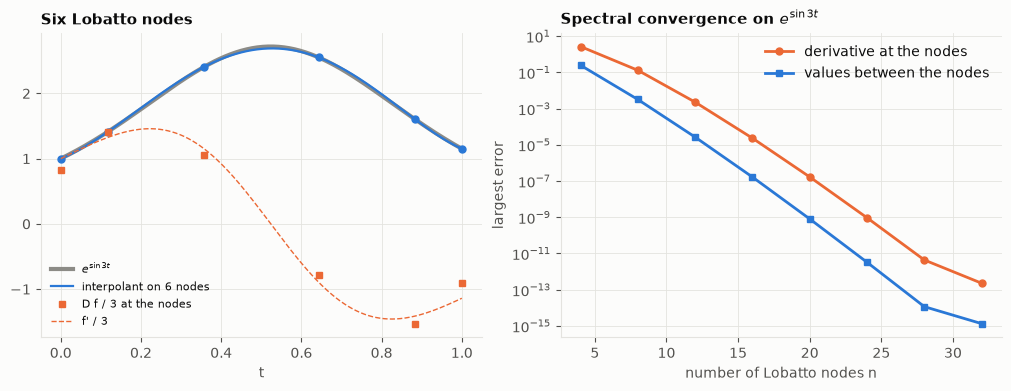

In [4]:
exact_error = 0.0
for nodes_of in FAMILIES.values():
  for n in QUADRATURE_POINTS:
    nodes = nodes_of(n)
    d = polynomial.differentiation_matrix(nodes)
    for k in range(n):
      exact_error = max(exact_error, float(np.abs(d @ nodes**k - k * nodes ** max(k - 1, 0)).max()))
print(f"D on 1, t, ..., t^(n-1), all three families, n = 2..8: largest error {exact_error:.1e}")


def signal(t):
  return np.exp(np.sin(3 * t))


def signal_rate(t):
  return 3 * np.cos(3 * t) * signal(t)


SPECTRAL_POINTS = (4, 8, 12, 16, 20, 24, 28, 32)
FINE = np.linspace(0.0, 1.0, 101)
derivative_errors, interpolation_errors = [], []
for n in SPECTRAL_POINTS:
  nodes = polynomial.lobatto_nodes(n)
  derivative_errors.append(float(np.abs(polynomial.differentiation_matrix(nodes) @ signal(nodes) - signal_rate(nodes)).max()))
  interpolation_errors.append(float(np.abs(polynomial.interpolation_matrix(nodes, FINE) @ signal(nodes) - signal(FINE)).max()))
print(f"{'n':>4} {'D error':>9} {'interpolation error':>20}")
for n, de, ie in zip(SPECTRAL_POINTS, derivative_errors, interpolation_errors, strict=True):
  print(f"{n:>4} {de:>9.1e} {ie:>20.1e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
nodes = polynomial.lobatto_nodes(6)
ax1.plot(fine, signal(fine), color=plotstyle.NEUTRAL, lw=3, label="$e^{\\sin 3t}$")
ax1.plot(fine, polynomial.interpolation_matrix(nodes, fine) @ signal(nodes), color=plotstyle.BLUE, lw=1.6, label="interpolant on 6 nodes")
ax1.plot(nodes, signal(nodes), "o", color=plotstyle.BLUE)
ax1.plot(nodes, polynomial.differentiation_matrix(nodes) @ signal(nodes) / 3, "s", color=plotstyle.ORANGE, label="D f / 3 at the nodes")
ax1.plot(fine, signal_rate(fine) / 3, color=plotstyle.ORANGE, lw=1, ls="--", label="f' / 3")
ax1.set_xlabel("t")
ax1.set_title("Six Lobatto nodes")
ax1.legend(loc="lower left", fontsize=8)
ax2.semilogy(SPECTRAL_POINTS, derivative_errors, "o-", color=plotstyle.ORANGE, label="derivative at the nodes")
ax2.semilogy(SPECTRAL_POINTS, interpolation_errors, "s-", color=plotstyle.BLUE, label="values between the nodes")
ax2.set_xlabel("number of Lobatto nodes n")
ax2.set_ylabel("largest error")
ax2.set_title("Spectral convergence on $e^{\\sin 3t}$")
ax2.legend()
plt.show()

On a semilog plot exponential convergence is a straight line, and both errors follow one: each four
more nodes gain about two digits, until the interpolant reaches rounding, $1.3 \times 10^{-15}$ at 32
nodes, and the derivative $2.3 \times 10^{-13}$. The derivative's error is 100 to 300 times the
interpolant's, since differentiating amplifies the interpolation error by up to the norm of $D$,
which grows like $n^2$. The left panel shows the same gap at six nodes: the interpolant lies on the
function within the line width, while the derivative at the nodes is visibly off.

## Collocation tableaus

A collocation method with nodes $c_1, \dots, c_s$ finds the polynomial of degree $s$ that starts at
$x$ and satisfies the ODE at $t + c_i h$. Written as a Runge-Kutta method, its coefficients are the
integrals of the Lagrange basis on the nodes,

$$
a_{ij} = \int_0^{c_i} l_j(\tau)\, d\tau, \qquad b_j = \int_0^1 l_j(\tau)\, d\tau ,
$$

one call of `lagrange_integrals(c, [c_1, ..., c_s, 1])`. Gauss nodes give the Gauss-Legendre
methods of order $2s$, Radau nodes Radau IIA of order $2s - 1$, Lobatto nodes Lobatto IIIA of order
$2s - 2$: the order of the quadrature on the same nodes. The published coefficients are from Hairer
and Wanner, *Solving Ordinary Differential Equations II*, section IV.5.

In [5]:
S3, S6 = np.sqrt(3.0), np.sqrt(6.0)
PUBLISHED = {
  "gauss_legendre2": ([[1 / 4, 1 / 4 - S3 / 6], [1 / 4 + S3 / 6, 1 / 4]], [1 / 2, 1 / 2], [1 / 2 - S3 / 6, 1 / 2 + S3 / 6]),
  "radau_iia3": (
    [
      [(88 - 7 * S6) / 360, (296 - 169 * S6) / 1800, (-2 + 3 * S6) / 225],
      [(296 + 169 * S6) / 1800, (88 + 7 * S6) / 360, (-2 - 3 * S6) / 225],
      [(16 - S6) / 36, (16 + S6) / 36, 1 / 9],
    ],
    [(16 - S6) / 36, (16 + S6) / 36, 1 / 9],
    [(4 - S6) / 10, (4 + S6) / 10, 1.0],
  ),
  "lobatto_iiia3": ([[0.0, 0.0, 0.0], [5 / 24, 1 / 3, -1 / 24], [1 / 6, 2 / 3, 1 / 6]], [1 / 6, 2 / 3, 1 / 6], [0.0, 1 / 2, 1.0]),
}
tableau_errors = {}
for tab in (si.gauss_legendre(2), si.radau_iia(3), si.lobatto_iiia(3)):
  a, b, c = (np.array(v) for v in PUBLISHED[tab.name])
  tableau_errors[tab.name] = float(max(np.abs(tab.a - a).max(), np.abs(tab.b - b).max(), np.abs(tab.c - c).max()))
  print(f"{tab.name} against the published coefficients: {tableau_errors[tab.name]:.1e}")

radau = si.radau_iia(3)
print("\nradau_iia3, c | A, then b:")
for c, row in zip(radau.c, radau.a, strict=True):
  print(f"{c:9.6f} | " + " ".join(f"{v:10.6f}" for v in row))
print(" " * 9 + " | " + " ".join(f"{v:10.6f}" for v in radau.b))

TABLEAU_STAGES = (2, 3, 4)
tableau_orders = {}
for family in (si.gauss_legendre, si.radau_iia, si.lobatto_iiia):
  tableau_orders[family.__name__] = [si.order_conditions(t.a, t.b, t.order + 1) for t in (family(s) for s in TABLEAU_STAGES)]
print(f"\norder conditions reached (declared order + 1 tested), s = {TABLEAU_STAGES}: {tableau_orders}")

gauss_legendre2 against the published coefficients: 1.1e-16
radau_iia3 against the published coefficients: 3.3e-16
lobatto_iiia3 against the published coefficients: 3.3e-16

radau_iia3, c | A, then b:
 0.155051 |   0.196815  -0.065535   0.023771
 0.644949 |   0.394424   0.292073  -0.041549
 1.000000 |   0.376403   0.512486   0.111111
          |   0.376403   0.512486   0.111111

order conditions reached (declared order + 1 tested), s = (2, 3, 4): {'gauss_legendre': [4, 6, 8], 'radau_iia': [3, 5, 7], 'lobatto_iiia': [2, 4, 6]}


The three tableaus match their closed forms to $3 \times 10^{-16}$, and the order conditions stop
exactly at $2s$, $2s - 1$ and $2s - 2$. Radau IIA's last row of $A$ equals $b$: the step is the last
stage, which is what makes the method stiffly accurate.

The nodes decide more than the order. On $x' = \lambda x$ each method multiplies $x$ by
$R(h\lambda) = 1 + h\lambda\, b^\top (I - h\lambda A)^{-1} \mathbf{1}$, and far out on the negative
real axis the three families part ways:

 gauss_legendre3: |R(-1e5)| = 1.00e+00
      radau_iia3: |R(-1e5)| = 3.00e-05
   lobatto_iiia3: |R(-1e5)| = 1.00e+00


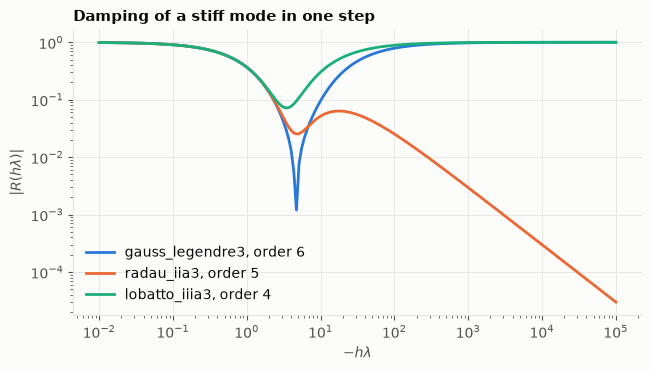

In [6]:
def stability(tab: si.Tableau, z: complex) -> complex:
  return 1 + z * tab.b @ np.linalg.solve(np.eye(tab.stages) - z * tab.a, np.ones(tab.stages))


stiffness = np.geomspace(1e-2, 1e5, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for tab, color in zip((si.gauss_legendre(3), si.radau_iia(3), si.lobatto_iiia(3)), plotstyle.SERIES, strict=False):
  magnitude = [abs(stability(tab, complex(-x))) for x in stiffness]
  ax.loglog(stiffness, magnitude, color=color, label=f"{tab.name}, order {tab.order}")
  print(f"{tab.name:>16}: |R(-1e5)| = {magnitude[-1]:.2e}")
ax.set_xlabel(r"$-h\lambda$")
ax.set_ylabel(r"$|R(h\lambda)|$")
ax.set_title("Damping of a stiff mode in one step")
ax.legend(loc="lower left")
plt.show()

All three are A-stable, and on the negative real axis $|R| \le 1$ throughout. Gauss-Legendre and
Lobatto IIIA keep $|R| \to 1$ as $h\lambda \to -\infty$, so a stiff mode is carried along
undamped. Radau IIA sends it to 0 like $1/(h\lambda)$, which is L-stability: $|R(-10^5)| = 3 \times 10^{-5}$.

## A generated spectral derivative

The matrices are constants, so a Function that uses them folds them into the generated code. This
one takes 32 samples of a signal at the Lobatto points of $[0, T]$ and returns its derivative at
those points, $D f / T$, and its integral over $[0, T]$, $T\, w^\top f$: pseudospectral
differentiation and Gauss-Lobatto quadrature of sampled data, in one C function whose only inputs
are the samples and $T$.

polynomials_spectral('samples', 'duration') -> ('rate', 'integral')
derivative against the closed form: 3.7e-10; integral 2.334372888585266 against quad: 8.9e-16


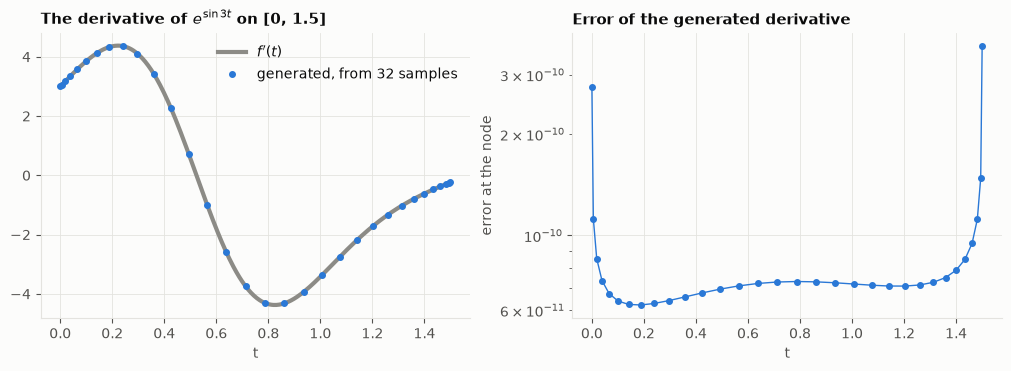

In [7]:
SAMPLES = 32
DURATION = 1.5
NODES = polynomial.lobatto_nodes(SAMPLES)
D = polynomial.differentiation_matrix(NODES)
WEIGHTS = polynomial.lagrange_integrals(NODES, np.ones(1))[0]


@sc.function(SAMPLES, (), output=sc.G("rate", "integral"), name="polynomials_spectral")
def spectral(samples, duration):
  """The derivative at the nodes and the integral over ``[0, duration]`` of the polynomial through
  ``samples``, taken at the times ``duration * NODES``."""
  return (sc.const(D) @ samples) / duration, (sc.const(WEIGHTS) @ samples) * duration


times = DURATION * NODES
rate, integral = spectral(signal(times), np.array(DURATION))
area = quad(signal, 0.0, DURATION, epsabs=1e-13, epsrel=1e-13)[0]
spectral_rate_error = float(np.abs(rate - signal_rate(times)).max())
spectral_integral_error = float(abs(integral - area))
print(f"{spectral.name}{spectral.input_names} -> {spectral.output_names}")
print(f"derivative against the closed form: {spectral_rate_error:.1e}; integral {float(integral):.15f} against quad: {spectral_integral_error:.1e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
curve = np.linspace(0.0, DURATION, 400)
ax1.plot(curve, signal_rate(curve), color=plotstyle.NEUTRAL, lw=3, label="$f'(t)$")
ax1.plot(times, rate, "o", color=plotstyle.BLUE, ms=4, label="generated, from 32 samples")
ax1.set_xlabel("t")
ax1.set_title(f"The derivative of $e^{{\\sin 3t}}$ on [0, {DURATION}]")
ax1.legend(loc="upper right")
ax2.semilogy(times, np.maximum(np.abs(rate - signal_rate(times)), 1e-17), "o-", color=plotstyle.BLUE, ms=4, lw=1)
ax2.set_xlabel("t")
ax2.set_ylabel("error at the node")
ax2.set_title("Error of the generated derivative")
plt.show()

Over $[0, 1.5]$ the signal oscillates more than over $[0, 1]$, so 32 nodes give $3.7 \times 10^{-10}$
here rather than the $2.3 \times 10^{-13}$ of the unit interval. The error is largest at the two
ends, where the Lagrange polynomials are steepest. The integral agrees with `quad` to
$9 \times 10^{-16}$.

## Checks

In [8]:
ns = range(2, 9)
assert quadrature_degree == {"gauss": [2 * n - 1 for n in ns], "radau": [2 * n - 2 for n in ns], "lobatto": [2 * n - 3 for n in ns]}
assert all(error > 1e-10 for error in quadrature_next_degree_error.values())  # and not one degree more
assert exact_error < 1e-13
for key, values, last in (("derivative", derivative_errors, 3e-12), ("interpolation", interpolation_errors, 1.5e-14)):
  assert all(np.diff(values) < 0) and values[-1] < last, key
assert all(error < 1e-14 for error in tableau_errors.values())
assert tableau_orders == {"gauss_legendre": [4, 6, 8], "radau_iia": [3, 5, 7], "lobatto_iiia": [2, 4, 6]}
assert spectral_rate_error < 4e-9 and spectral_integral_error < 1e-14
print("8 checks passed")

8 checks passed


## The generated C

`D` and `w` become two `static const` tables, of 1024 and 32 doubles, and the products are loops
over them. The listing cuts the tables' lines short.

In [9]:
module = write_module(spectral, GENERATED)
lines = module.source.splitlines()
print(f"{module.source_name}: {len(lines)} lines, {len(module.source) / 1e3:.1f} kB")
start = next(i for i, line in enumerate(lines) if line.startswith(f"int {spectral.name}("))
end = max(i for i, line in enumerate(lines) if line.startswith("#ifdef __cplusplus"))
print("\n".join(line if len(line) < 110 else line[:100] + " ..." for line in lines[start:end] if line.strip()))

polynomials_spectral.c: 58 lines, 23.5 kB
int polynomials_spectral(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  if (!res[1]) return SCALY_ERR_NULL_RESULT;
  static const double k0[1024] = {-496.00000000000108, 671.02922197403393, -268.62884726943219, 153. ...
  double s0[32];
  static const double k2[32] = {0.0010080645161290249, 0.0061990532506872344, 0.01109977644464645, 0 ...
  for (long long i_t1 = 0; i_t1 < 32; ++i_t1) {
    s0[i_t1] = 0.0;
  }
  for (long long ib_t1 = 0; ib_t1 < 8; ++ib_t1) {
    for (long long k_t1 = 0; k_t1 < 32; ++k_t1) {
      int64_t v0 = (ib_t1 * 4);
      s0[v0] = (s0[v0] + (k0[((v0 * 32) + k_t1)] * arg[0][k_t1]));
      int64_t v1 = ((ib_t1 * 4) + 1);
      s0[v1] = (s0[v1] + (k0[((v1 * 32) + k_t1)] * arg[0][k_t1]));
    